In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')
 

iris = load_iris()
X = iris.data
y_true = iris.target
feature_names = iris.feature_names
 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
print("Dataset shape:", X.shape)
print("Features:", feature_names)
print("True class distribution:", np.bincount(y_true))

Dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
True class distribution: [50 50 50]



EXPERIMENT 1: K-Means Clustering
Cluster centers shape: (3, 4)
Inertia (WCSS): 139.82
Silhouette Score: 0.4599
Adjusted Rand Index (vs true labels): 0.6201


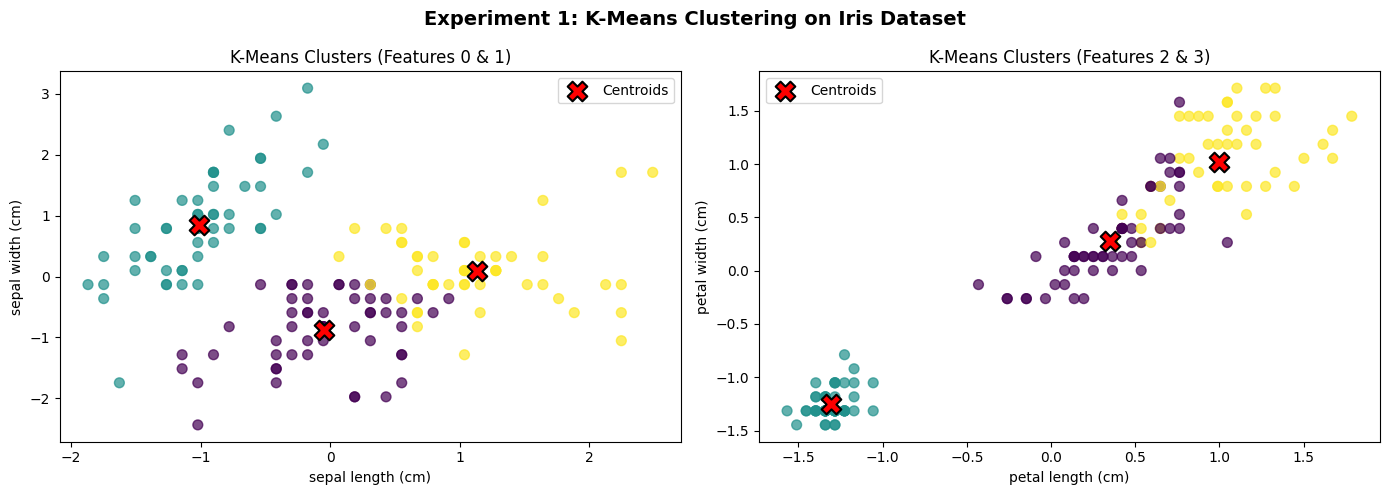

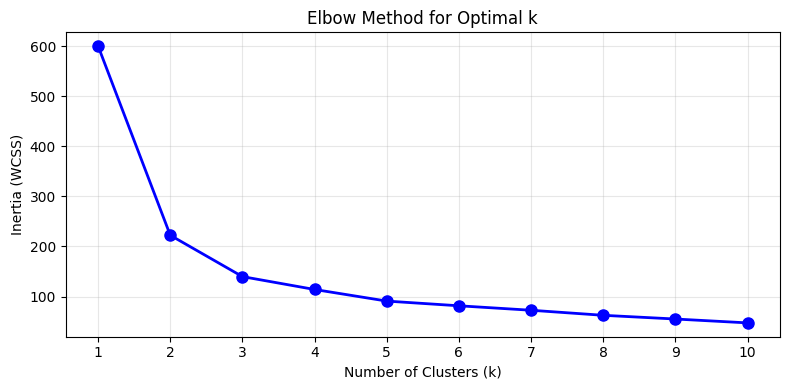

In [2]:
print("\n" + "="*60)
print("EXPERIMENT 1: K-Means Clustering")
print("="*60)
 
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)
 
print(f"Cluster centers shape: {kmeans.cluster_centers_.shape}")
print(f"Inertia (WCSS): {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, km_labels):.4f}")
print(f"Adjusted Rand Index (vs true labels): {adjusted_rand_score(y_true, km_labels):.4f}")
 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=km_labels, cmap='viridis', s=50, alpha=0.7)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c='red', marker='X', s=200, edgecolors='black', linewidths=1.5, label='Centroids')
axes[0].set_xlabel(feature_names[0])
axes[0].set_ylabel(feature_names[1])
axes[0].set_title("K-Means Clusters (Features 0 & 1)")
axes[0].legend()
 
axes[1].scatter(X_scaled[:, 2], X_scaled[:, 3], c=km_labels, cmap='viridis', s=50, alpha=0.7)
axes[1].scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3],
                c='red', marker='X', s=200, edgecolors='black', linewidths=1.5, label='Centroids')
axes[1].set_xlabel(feature_names[2])
axes[1].set_ylabel(feature_names[3])
axes[1].set_title("K-Means Clusters (Features 2 & 3)")
axes[1].legend()
 
plt.suptitle("Experiment 1: K-Means Clustering on Iris Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 

inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
 
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 


EXPERIMENT 2: Agglomerative Clustering + Dendrogram
Silhouette Score: 0.4467
Adjusted Rand Index (vs true labels): 0.6153


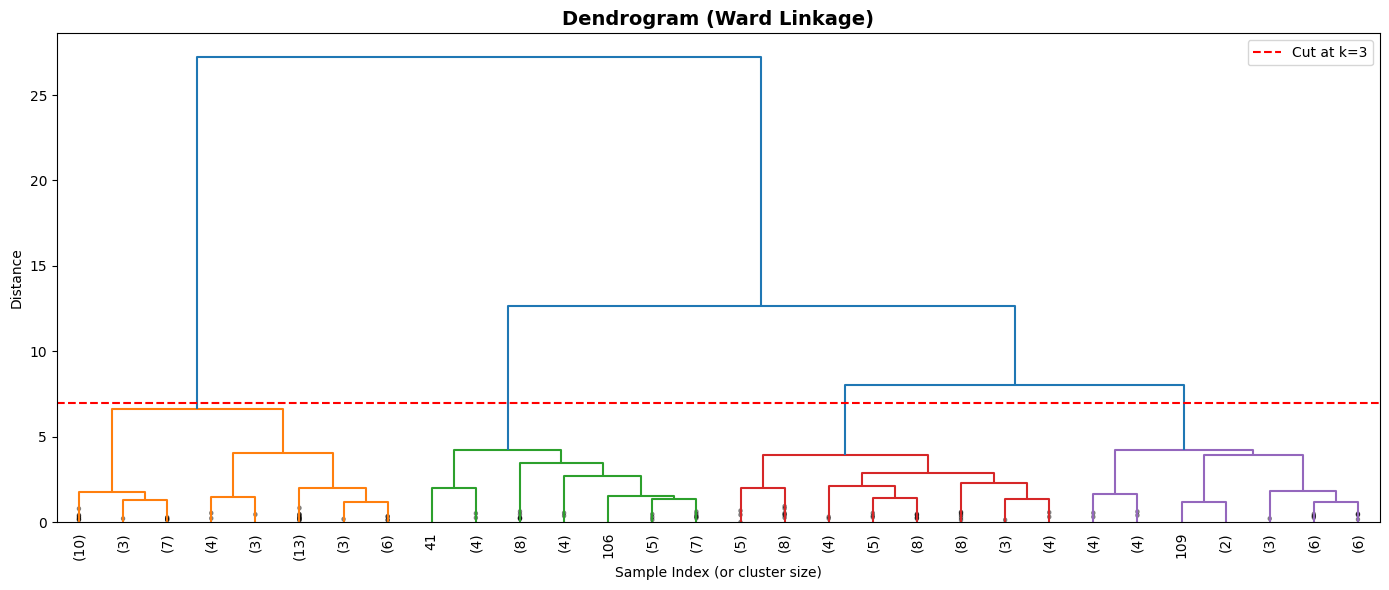

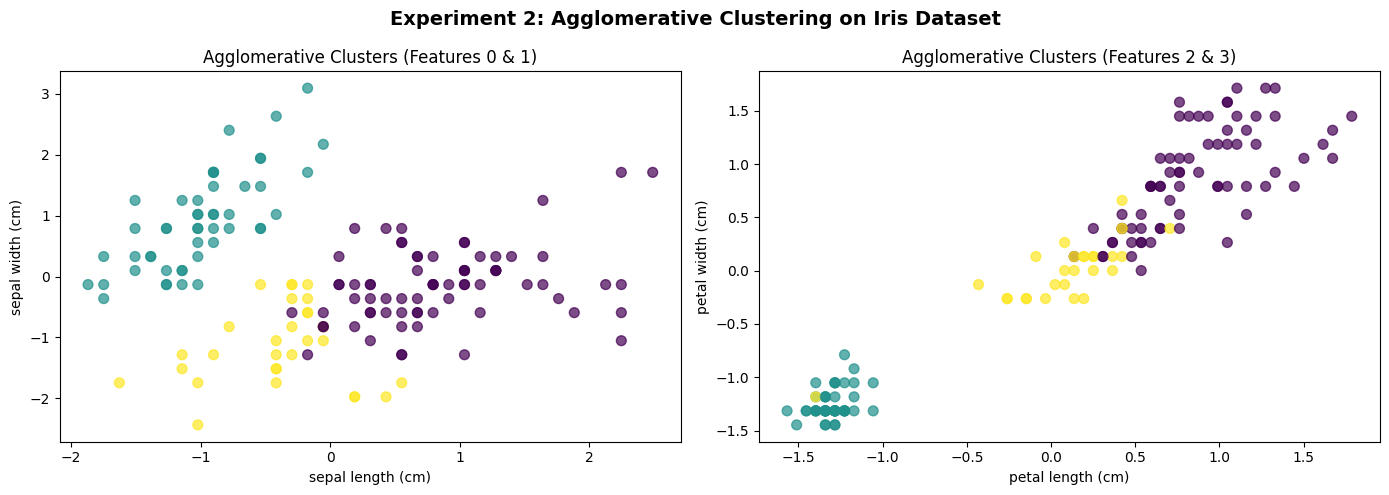

In [3]:
print("\n" + "="*60)
print("EXPERIMENT 2: Agglomerative Clustering + Dendrogram")
print("="*60)
 
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)
 
print(f"Silhouette Score: {silhouette_score(X_scaled, agg_labels):.4f}")
print(f"Adjusted Rand Index (vs true labels): {adjusted_rand_score(y_true, agg_labels):.4f}")
 
# Dendrogram
linked = linkage(X_scaled, method='ward')
 
plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10,
           show_contracted=True, color_threshold=7)
plt.title("Dendrogram (Ward Linkage)", fontsize=14, fontweight='bold')
plt.xlabel("Sample Index (or cluster size)")
plt.ylabel("Distance")
plt.axhline(y=7, color='r', linestyle='--', label='Cut at k=3')
plt.legend()
plt.tight_layout()
plt.show()
 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=agg_labels, cmap='viridis', s=50, alpha=0.7)
axes[0].set_xlabel(feature_names[0])
axes[0].set_ylabel(feature_names[1])
axes[0].set_title("Agglomerative Clusters (Features 0 & 1)")
 
axes[1].scatter(X_scaled[:, 2], X_scaled[:, 3], c=agg_labels, cmap='viridis', s=50, alpha=0.7)
axes[1].set_xlabel(feature_names[2])
axes[1].set_ylabel(feature_names[3])
axes[1].set_title("Agglomerative Clusters (Features 2 & 3)")
 
plt.suptitle("Experiment 2: Agglomerative Clustering on Iris Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

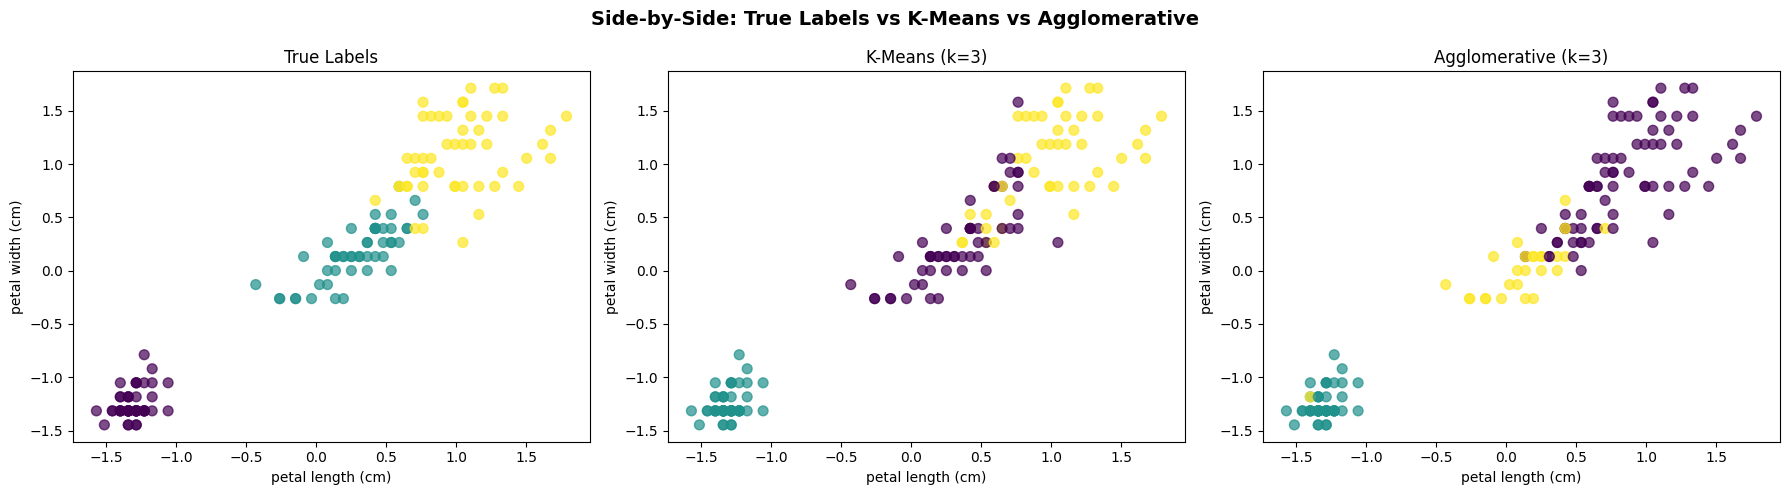


k     Method                 Silhouette      ARI       
----------------------------------------------------
2     K-Means                0.5818          0.5681    
      Agglomerative          0.5770          0.5438    
----------------------------------------------------
3     K-Means                0.4599          0.6201    
      Agglomerative          0.4467          0.6153    
----------------------------------------------------
4     K-Means                0.3869          0.4728    
      Agglomerative          0.4006          0.5879    
----------------------------------------------------


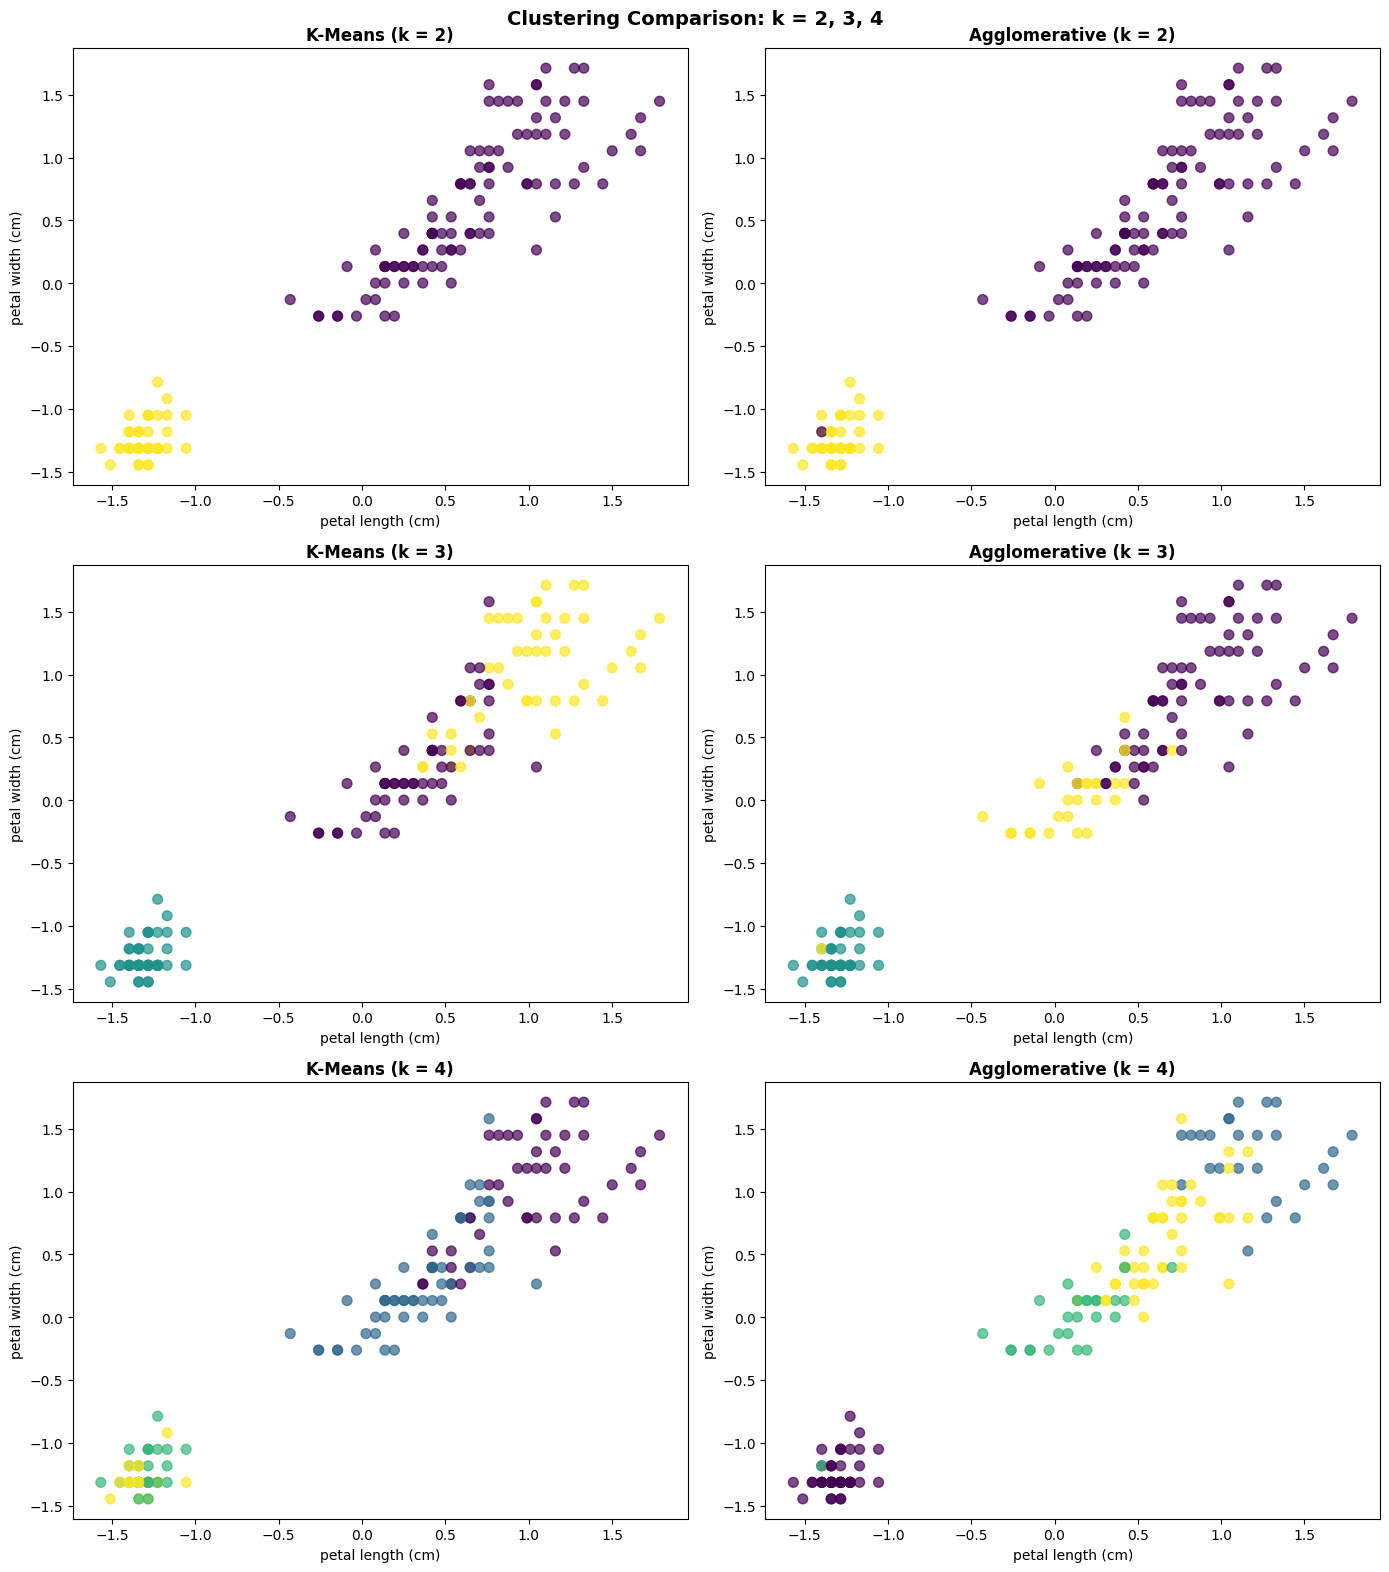

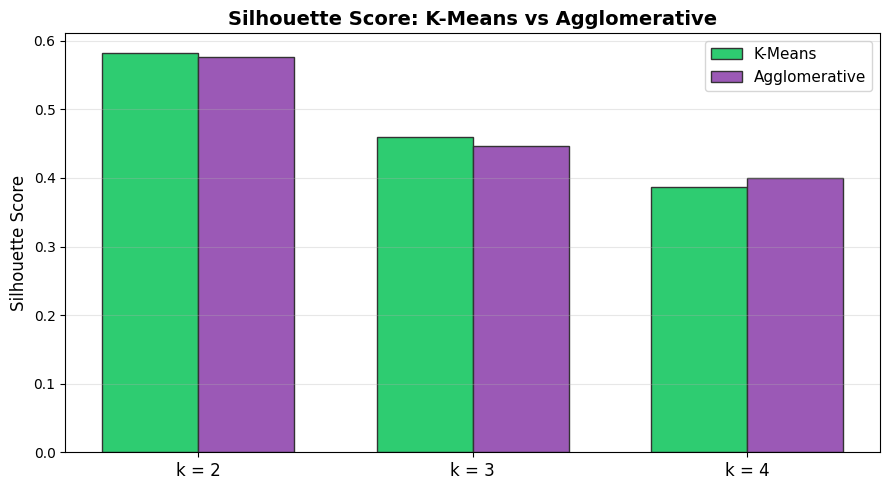


SUMMARY:
- k=2 merges Versicolor & Virginica into one cluster
- k=3 is optimal, matches the 3 true Iris species
- k=4 over-segments, splitting a clean cluster unnecessarily
- Both methods perform comparably on this dataset


In [5]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_scaled[:, 2], X_scaled[:, 3], c=y_true, cmap='viridis', s=50, alpha=0.7)
axes[0].set_xlabel('petal length (cm)')
axes[0].set_ylabel('petal width (cm)')
axes[0].set_title('True Labels')

axes[1].scatter(X_scaled[:, 2], X_scaled[:, 3], c=km_labels, cmap='viridis', s=50, alpha=0.7)
axes[1].set_xlabel('petal length (cm)')
axes[1].set_ylabel('petal width (cm)')
axes[1].set_title('K-Means (k=3)')

axes[2].scatter(X_scaled[:, 2], X_scaled[:, 3], c=agg_labels, cmap='viridis', s=50, alpha=0.7)
axes[2].set_xlabel('petal length (cm)')
axes[2].set_ylabel('petal width (cm)')
axes[2].set_title('Agglomerative (k=3)')

plt.suptitle('Side-by-Side: True Labels vs K-Means vs Agglomerative', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# --- Clustering for k = 2, 3, 4 ---
print(f"\n{'k':<5} {'Method':<22} {'Silhouette':<15} {'ARI':<10}")
print("-" * 52)

fig, axes = plt.subplots(3, 2, figsize=(14, 16))

for i, k in enumerate([2, 3, 4]):
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_lab = km_temp.fit_predict(X_scaled)

    agg_temp = AgglomerativeClustering(n_clusters=k, linkage='ward')
    agg_lab = agg_temp.fit_predict(X_scaled)

    km_sil = silhouette_score(X_scaled, km_lab)
    agg_sil = silhouette_score(X_scaled, agg_lab)
    km_ari = adjusted_rand_score(y_true, km_lab)
    agg_ari = adjusted_rand_score(y_true, agg_lab)

    print(f"{k:<5} {'K-Means':<22} {km_sil:<15.4f} {km_ari:<10.4f}")
    print(f"{'':5} {'Agglomerative':<22} {agg_sil:<15.4f} {agg_ari:<10.4f}")
    print("-" * 52)

    axes[i, 0].scatter(X_scaled[:, 2], X_scaled[:, 3], c=km_lab, cmap='viridis', s=50, alpha=0.7)
    axes[i, 0].set_title(f'K-Means (k = {k})', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel('petal length (cm)')
    axes[i, 0].set_ylabel('petal width (cm)')

    axes[i, 1].scatter(X_scaled[:, 2], X_scaled[:, 3], c=agg_lab, cmap='viridis', s=50, alpha=0.7)
    axes[i, 1].set_title(f'Agglomerative (k = {k})', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel('petal length (cm)')
    axes[i, 1].set_ylabel('petal width (cm)')

plt.suptitle('Clustering Comparison: k = 2, 3, 4', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# --- Silhouette Score Bar Chart ---
k_vals = [2, 3, 4]
sil_km, sil_agg = [], []

for k in k_vals:
    km_l = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    ag_l = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_scaled)
    sil_km.append(silhouette_score(X_scaled, km_l))
    sil_agg.append(silhouette_score(X_scaled, ag_l))

x = np.arange(len(k_vals))
w = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - w/2, sil_km, w, label='K-Means', color='#2ecc71', edgecolor='#333')
plt.bar(x + w/2, sil_agg, w, label='Agglomerative', color='#9b59b6', edgecolor='#333')
plt.xticks(x, [f'k = {k}' for k in k_vals], fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score: K-Means vs Agglomerative', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# --- Summary ---
print("\nSUMMARY:")
print("- k=2 merges Versicolor & Virginica into one cluster")
print("- k=3 is optimal, matches the 3 true Iris species")
print("- k=4 over-segments, splitting a clean cluster unnecessarily")
print("- Both methods perform comparably on this dataset")